# Report turbulence-CTD on 13 Jan 2026

Includes microCTD and CTD profiles at 3 locations (South Basin, Central Constriction, Western Constriction)

In [2]:
import os
import sys
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\..\..\scripts\functions\figures'))
from functions_figures import array_bands, get_cmap_discrete, compute_logmedian_list
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\..\..\scripts\functions\ctd'))
#from functions_ctd import thorpe_scale
sys.path.append(os.path.join(os.path.dirname(os.path.abspath("__file__")), r'..\..\..\scripts\functions\general_functions'))
from general_functions import read_netCDF_xr, datenum2timestamp
import numpy as np
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import cmocean
plt.rcParams['svg.fonttype'] = 'none'
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Arial'  # or any installed font
plt.close('all')


%matplotlib widget 

### Specify if using Renku or not:

In [3]:
using_Renku = False

In [4]:
if using_Renku:
    datafolder=os.path.join('..','..','..','..','data-lakezug')   
else:
    datafolder=os.path.join('..','..','..','data')
    # For interactive plots in Jupyter Notebook 
    %matplotlib widget     

Parameters

In [5]:
#%% Specify field campaign here:
campaign_name='20260113'
datalevel='Level2'
instrument='microCTD'
categories=['VMPS','VMPC','VMPW'] # Among profile names (CTD & microCTD)
colcat=[[50/255,100/255,214/255],[1, 0.4, 0.15],[0.1, 0.6, 0.3]]
colcat_light=[[140/255,170/255,230/255],[1, 0.75, 0.6],[0.5,0.8,0.5]]

# Relative path:
data_folder_rel=os.path.join('..','..','..','data',instrument,campaign_name,datalevel)

#folder_param_name='down1.0_K5.3_L_NAS0.0058_singlepole_nfft3_EPFL_Goodman'
fileprof=['DAT_053_down_prof1','DAT_053_down_prof2','DAT_053_down_prof3',
          'DAT_055_down_prof1','DAT_055_down_prof2','DAT_055_down_prof3',
          'DAT_057_down_prof1','DAT_057_down_prof2','DAT_057_down_prof3',
          'DAT_059_down_prof1','DAT_059_down_prof2'] # all files
fileprof=[f for f in os.listdir(data_folder_rel) if f.endswith('.nc')]
profnames=['VMPS','VMPS','VMPS',
           'VMPC','VMPC','VMPC',
           'VMPW','VMPW','VMPW',
           'VMPC','VMPC']

indS=np.where(np.array(profnames)=='VMPS')[0]
indC1=np.where(np.array(profnames)=='VMPC1')[0]
indW=np.where(np.array(profnames)=='VMPW')[0]
indC2=np.where(np.array(profnames)=='VMPC2')[0]

# CTD transect:
data_folder_rel_CTD=os.path.join(datafolder,'CTD',campaign_name,'Level3')
fileCTD='CTD_transect_'+campaign_name+'.nc'

# Individual profiles:
# data_folder_rel_CTD=os.path.join(datafolder,'CTD',campaign_name,'Level2')
# fileCTDprof=[f for f in os.listdir(data_folder_rel_CTD) if f.endswith('.nc')]

savefig=True

colmicro=plt.get_cmap('tab10',len(fileprof))

white_color_fraction=0.6
whitecol=np.array([1,1,1,1])



Load the data

In [6]:
# Bathymetry:
data_bathy=read_netCDF_xr(os.path.join('..','..','..','data','Bathymetry','Level2','bathymetry_Zug_10m.nc'))

# microCTD profiles:
dataprof=[]
datetime_micro=[]
for kf in range(len(fileprof)):
    filename_nolevel=fileprof[kf][fileprof[kf].find('_')+1:]
    if datalevel=='Level1':
        filename_full='L1_'+filename_nolevel
    elif datalevel=='Level2' or datalevel=='Level2_Qdrive':
        filename_full='L2_'+filename_nolevel
    else:
        raise Exception('Wrong level')
        
    dataprof.append(read_netCDF_xr(os.path.join(data_folder_rel,filename_full)))
    datetime_micro.append(pd.to_datetime(datenum2timestamp(dataprof[kf].SLOW_datenum.values[0])+dataprof[kf].SLOW_dtsec.values[0], unit='s'))

indcat=[np.where(np.array(profnames)==catname)[0] for catname in categories]

#%% CTD transect:
dataprof_CTD=read_netCDF_xr(os.path.join(data_folder_rel_CTD,fileCTD))
#datetime_CTD=dataprof_CTD.time.values.astype('datetime64[s]')
datetime_CTD=pd.to_datetime(dataprof_CTD.time.values, unit='s')
profnames_CTD=list(dataprof_CTD.profnames.values)

colCTD=get_cmap_discrete('tab10', len(dataprof_CTD.time))

indcat_CTD=[np.where(dataprof_CTD.profnames.values==catname)[0] for catname in categories]


Plot the map

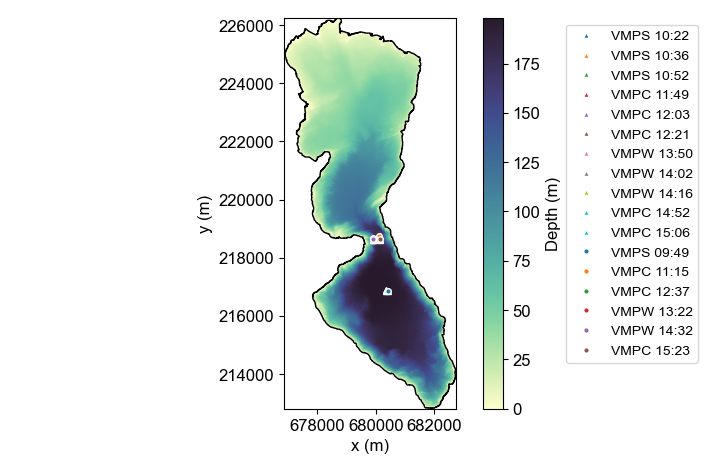

In [7]:
fig,ax = plt.subplots(1,1,figsize=(18 / 2.54, 12 / 2.54))  # Convert from cm to inches

hp=ax.pcolormesh(data_bathy.x-2e6, data_bathy.y-1e6,data_bathy.depth,vmin=0,vmax=np.nanmax(data_bathy.depth),cmap="cmo.deep")
ax.plot(data_bathy.x_contour-2e6, data_bathy.y_contour-1e6, color='k', linewidth=1)
ax.set_aspect("equal")
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
cb = fig.colorbar(hp, ax=ax)
cb.set_label('Depth (m)')

# Add the microCTD profiles:
for kf in range(len(fileprof)):
    if 'x_coord' in dataprof[kf].attrs.keys() and 'y_coord' in dataprof[kf].attrs.keys():
        ax.plot(int(dataprof[kf].x_coord), int(dataprof[kf].y_coord), marker='^', linestyle='', color=colmicro(kf), markersize=4, 
                markeredgecolor='w',markeredgewidth=1,label=profnames[kf]+' '+str(datetime_micro[kf].strftime('%H:%M')))

# Add the CTD profiles:
for kCTD in range(len(dataprof_CTD.time)):
    ax.plot(dataprof_CTD.xcoord[kCTD], dataprof_CTD.ycoord[kCTD], marker='o', linestyle='', color=colCTD(kCTD), markersize=4, 
            markeredgecolor='w',markeredgewidth=1,label=dataprof_CTD.profnames.values[kCTD]+' '+str(datetime_CTD[kCTD].strftime('%H:%M')))
#ax.plot(dataprof_CTD.xcoord[indS_CTD], dataprof_CTD.ycoord[indS_CTD], marker='o', linestyle='', color=colS, markersize=4, markeredgecolor='w',markeredgewidth=1,label='CTD_S')
#ax.plot(dataprof_CTD.xcoord[indC_CTD], dataprof_CTD.ycoord[indC_CTD], marker='o', linestyle='', color=colC1, markersize=4, markeredgecolor='w',markeredgewidth=1,label='CTD_C')
#ax.plot(dataprof_CTD.xcoord[indW_CTD], dataprof_CTD.ycoord[indW_CTD], marker='o', linestyle='', color=colW, markersize=4, markeredgecolor='w',markeredgewidth=1,label='CTD_W')

ax.legend(loc='upper left',bbox_to_anchor=(1.6, 1), fontsize=10)

fig.set_tight_layout(True)

Plot the microCTD profiles

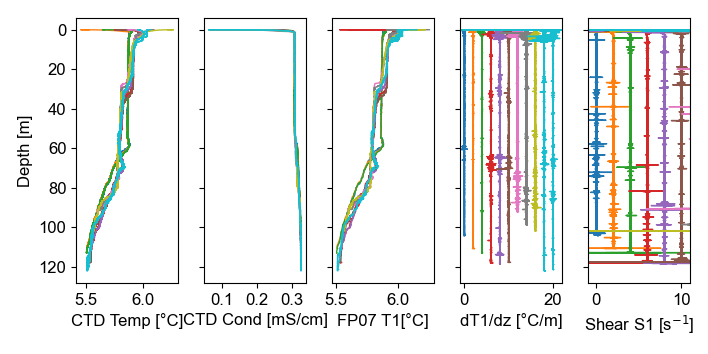

In [20]:

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,5,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches
Tsensor='T1'
Ssensor='S1'

for kf in range(len(dataprof)):
    ax[0].plot(dataprof[kf].SLOW_temperature.data,dataprof[kf].SLOW_depth,linewidth=1,color=colmicro(kf))
    
    ax[1].plot(dataprof[kf].SLOW_conductivity20.data/1000,dataprof[kf].SLOW_depth,linewidth=1,color=colmicro(kf))
    
    ax[2].plot(dataprof[kf]['FAST_fast_'+Tsensor].data,dataprof[kf].FAST_depth,linewidth=1,color=colmicro(kf))
    
    ax[3].plot(dataprof[kf]['FAST_grad_'+Tsensor].data+2*kf,dataprof[kf].FAST_depth,linewidth=1,color=colmicro(kf))
    
    ax[4].plot(dataprof[kf]['FAST_fast_'+Ssensor].data+2*kf,dataprof[kf].FAST_depth,linewidth=1,color=colmicro(kf))


# Labels and limits:
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('CTD Temp [°C]')
ax[1].set_xlabel('CTD Cond [mS/cm]')
ax[2].set_xlabel('FP07 '+Tsensor+'[°C]')
ax[3].set_xlabel('d'+Tsensor+'/dz [°C/m]')
ax[4].set_xlabel('Shear '+Ssensor+' [s$^{-1}$]')

ax[3].set_xlim(-1,2*len(dataprof))
ax[4].set_xlim(-1,len(dataprof))
ax[0].invert_yaxis()

fig.set_tight_layout(True)

if savefig:
    fig.savefig('comparison_prof_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_prof_'+campaign_name+'.svg',dpi=400)



Plot the turbulence data from the microCTD profiles

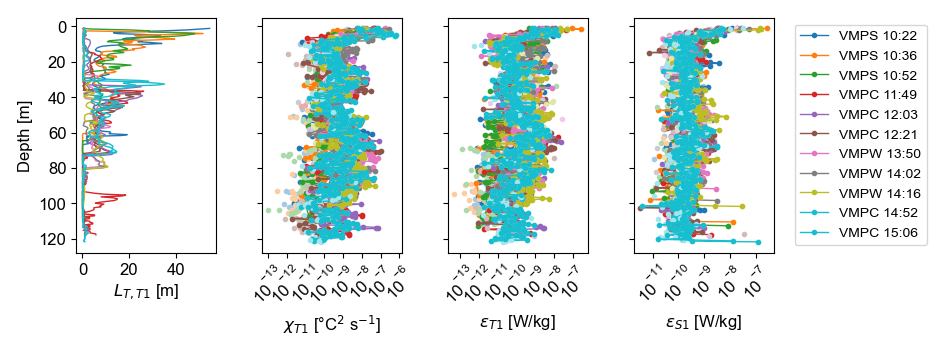

In [21]:

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,4,figsize=(24 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches
Tsensor='T1'

for kf in range(len(dataprof)):
    pale_color = white_color_fraction * whitecol + (1-white_color_fraction) * np.array(colmicro(kf))
    
    indkeep_T=np.where(dataprof[kf]['BINNED_flag_'+Tsensor].data==0)[0]
    indkeep_S1=np.where(dataprof[kf].BINNED_flag_S1.data==0)[0]
    
    ax[0].plot(dataprof[kf]['BINNED_LTu'+Tsensor].data,dataprof[kf].BINNED_depth.data,'-',linewidth=1,color=colmicro(kf))
    
    ax[1].plot(dataprof[kf]['BINNED_Xi_'+Tsensor].data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[1].plot(dataprof[kf]['BINNED_Xi_'+Tsensor].data[indkeep_T],dataprof[kf].BINNED_depth.data[indkeep_T],'.-',linewidth=1,color=colmicro(kf))
    
    ax[2].plot(dataprof[kf]['BINNED_eps_'+Tsensor].data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[2].plot(dataprof[kf]['BINNED_eps_'+Tsensor].data[indkeep_T],dataprof[kf].BINNED_depth.data[indkeep_T],'.-',linewidth=1,color=colmicro(kf))
    
    ax[3].plot(dataprof[kf].BINNED_eps_S1.data,dataprof[kf].BINNED_depth.data,'.',linewidth=1,color=pale_color)
    ax[3].plot(dataprof[kf].BINNED_eps_S1.data[indkeep_S1],dataprof[kf].BINNED_depth.data[indkeep_S1],'.-',linewidth=1,color=colmicro(kf),label=profnames[kf]+' '+str(datetime_micro[kf].strftime('%H:%M')))
    
    
# Labels and limits:
ax[0].set_ylabel('Depth [m]')
ax[0].set_xlabel('$L_{T,'+Tsensor+'}$ [m]')
ax[1].set_xlabel('$\\chi_{'+Tsensor+'}$ [°C$^2$ s$^{-1}$]')
ax[2].set_xlabel('$\\varepsilon_{'+Tsensor+'}$ [W/kg]')
ax[3].set_xlabel('$\\varepsilon_{S1}$ [W/kg]')

xlimval=ax[0].get_xlim()
ax[0].set_xticks(np.arange(0, 100, 20))
ax[0].set_xlim(xlimval)

ax[1].set_xscale('log')
xlimval=ax[1].get_xlim()
ax[1].set_xticks(10.0**np.arange(-14, -5, 1))
ax[1].set_xlim(xlimval)
ax[1].tick_params(axis='x', labelrotation=45)

ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, -5, 1))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)

ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, -5, 1))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)

ax[0].invert_yaxis()

ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

if savefig:
    fig.savefig('comparison_turbulence_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_'+campaign_name+'.svg',dpi=400)



Plot averaged turbulence profiles

In [22]:
# Compute log-median profiles for the different categories, by keeping only bins without flags:
depthcell=5 # [m]

plot_data=dict()
varlogmed=["LTu","eps_","Xi_","KOsbornCox_"]
for var in varlogmed:
    plot_data[var]={"depth_all":[], "values_all":[], "depth_cells":[], "logmed":[]}
    for kcat in range(len(categories)):
        if len(indcat[kcat])>0:
            depth_all, values_all, depth_cells, logmed = compute_logmedian_list([dataprof[i]["BINNED_depth"].values[dataprof[i]["BINNED_flag_T1"].values==0] for i in indcat[kcat]],[dataprof[i]["BINNED_"+var+"T1"].values[dataprof[i]["BINNED_flag_T1"].values==0] for i in indcat[kcat]], depthcell)
            # Include both T1 and T2:
            #depth_all, values_all, depth_cells, logmed = compute_logmedian_list([dataprof[i]["BINNED_depth"].values[dataprof[i]["BINNED_flag_T1"].values==0] for i in indcat[kcat]]+
                                                                                #[dataprof[i]["BINNED_depth"].values[dataprof[i]["BINNED_flag_T2"].values==0] for i in indcat[kcat]],
                                                                            # [dataprof[i]["BINNED_"+var+'T1'].values[dataprof[i]["BINNED_flag_T1"].values==0] for i in indcat[kcat]]+
                                                                                #[dataprof[i]["BINNED_"+var+'T2'].values[dataprof[i]["BINNED_flag_T2"].values==0] for i in indcat[kcat]], depthcell)
            plot_data[var]["depth_all"].append(depth_all)
            plot_data[var]["values_all"].append(values_all)
            plot_data[var]["depth_cells"].append(depth_cells)
            plot_data[var]["logmed"].append(logmed)

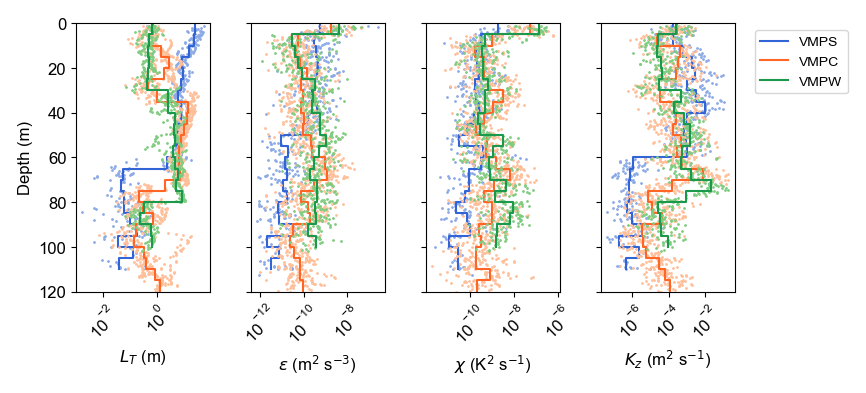

In [24]:
depthmax=120 # [m]

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,4,figsize=(22 / 2.54, 10 / 2.54),sharey=True)  # Convert from cm to inches

# 1st subplot: Thorpe-T1
for kcat in range(len(plot_data["LTu"]["values_all"])):
        ax[0].plot(plot_data["LTu"]["values_all"][kcat], plot_data["LTu"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
        ax[0].plot(10**plot_data["LTu"]["logmed"][kcat], plot_data["LTu"]["depth_cells"][kcat], '-', color=colcat[kcat])
ax[0].set_ylabel('Depth (m)')
ax[0].set_xlabel(r'$L_{T}$ (m)')
ax[0].set_xscale('log')
xlimval=ax[0].get_xlim()
ax[0].set_xticks(10.0**np.arange(-14, 1, 2))
ax[0].set_xlim(xlimval)
ax[0].tick_params(axis='x', labelrotation=45)

# 2nd subplot: Eps-T1
for kcat in range(len(plot_data["LTu"]["values_all"])):
        ax[1].plot(plot_data["eps_"]["values_all"][kcat], plot_data["eps_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
        ax[1].plot(10**plot_data["eps_"]["logmed"][kcat], plot_data["eps_"]["depth_cells"][kcat], '-', color=colcat[kcat])
ax[1].set_xlabel(r'$\epsilon$ (m$^2$ s$^{-3}$)')
ax[1].set_xscale('log')
xlimval=ax[1].get_xlim()
ax[1].set_xticks(10.0**np.arange(-14, 1, 2))
ax[1].set_xlim(xlimval)
ax[1].tick_params(axis='x', labelrotation=45)
#ax[1].set_xlim([10**(-11), 10**(-4)])


# 3rd subplot: X-T1
for kcat in range(len(plot_data["LTu"]["values_all"])):
        ax[2].plot(plot_data["Xi_"]["values_all"][kcat], plot_data["Xi_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
        ax[2].plot(10**plot_data["Xi_"]["logmed"][kcat], plot_data["Xi_"]["depth_cells"][kcat], '-', color=colcat[kcat])
ax[2].set_xlabel(r'$\chi$ (K$^2$ s$^{-1}$)')
ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, 1, 2))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)
#ax[2].set_xlim([10**(-13), 10**(-6)])

# 4th subplot: Kz-T1
for kcat in range(len(plot_data["LTu"]["values_all"])):
        ax[3].plot(plot_data["KOsbornCox_"]["values_all"][kcat], plot_data["KOsbornCox_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
        ax[3].plot(10**plot_data["KOsbornCox_"]["logmed"][kcat], plot_data["KOsbornCox_"]["depth_cells"][kcat], '-', color=colcat[kcat],label=categories[kcat])
ax[3].set_xlabel(r'$K_{z}$ (m$^2$ s$^{-1}$)')
ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, 1, 2))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)


ax[0].set_ylim((0,depthmax))
ax[0].invert_yaxis()  # Reverse the y-axis 
ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('comparison_turbulence_avg_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_avg_'+campaign_name+'.svg',dpi=1000)



Plot CTD profiles

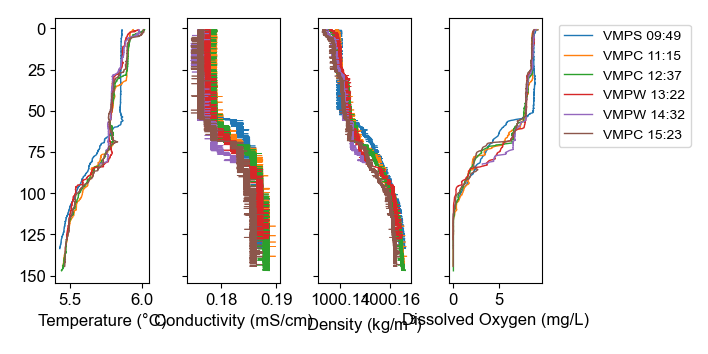

In [30]:

fig,ax = plt.subplots(1,4,figsize=(18 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

# Plot CTD profiles
for kprof in range(len(dataprof_CTD.time)):
    ax[0].plot(dataprof_CTD["temp"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=1)
    ax[1].plot(dataprof_CTD["cond"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[2].plot(dataprof_CTD["rho"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[3].plot(dataprof_CTD["DO"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=1,label=profnames_CTD[kprof]+' '+str(datetime_CTD[kprof].strftime('%H:%M')))
    
ax[0].set_xlabel('Temperature (°C)')
ax[1].set_xlabel('Conductivity (mS/cm)')
ax[2].set_xlabel('Density (kg/m$^3$)')
ax[2].ticklabel_format(useOffset=False, style='plain', axis='x')
ax[3].set_xlabel('Dissolved Oxygen (mg/L)')
ax[0].invert_yaxis()  # Reverse the y-axis 

ax[3].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)


fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_profiles_'+campaign_name+'.png',dpi=400)
    fig.savefig('CTD_profiles_'+campaign_name+'.svg',dpi=1000)

    


Plot temp-DO profiles or density-DO profiles

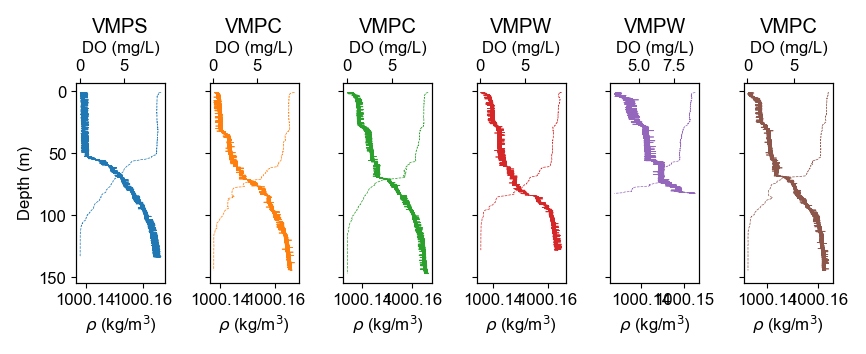

In [31]:

fig,ax = plt.subplots(1,len(dataprof_CTD.time),figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches

# Plot CTD profiles
for kprof in range(len(dataprof_CTD.time)):
    #ax[kprof].plot(dataprof_CTD["temp"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax[kprof].plot(dataprof_CTD["rho"].values[:,kprof], dataprof_CTD["depth"].values, color=colCTD(kprof), linewidth=0.5)
    ax2=ax[kprof].twiny()
    ax2.plot(dataprof_CTD["DO"].values[:,kprof], dataprof_CTD["depth"].values, '--', color=colCTD(kprof), linewidth=0.5)
    
    #ax[kprof].set_xlabel('T (°C)')
    ax[kprof].set_xlabel('$\\rho$ (kg/m$^3$)')
    ax2.set_xlabel('DO (mg/L)')
    ax[kprof].set_title(dataprof_CTD.profnames.values[kprof])

    ax[kprof].ticklabel_format(useOffset=False, style='plain', axis='x')
ax[0].invert_yaxis()  # Reverse the y-axis
ax[0].set_ylabel('Depth (m)') 


fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('CTD_profiles_tempDO_'+campaign_name+'.png',dpi=400)
    #fig.savefig('CTD_profiles_tempDO_'+campaign_name+'.svg',dpi=1000)



Plot turbulence and DO on the same figure

In [33]:
dataprof_CTD

<xarray.Dataset>
Dimensions:        (depth: 20000, time: 6)
Coordinates:
  * time           (time) float64 1.768e+09 1.768e+09 ... 1.768e+09 1.768e+09
  * depth          (depth) float64 0.0 0.01 0.02 0.03 ... 200.0 200.0 200.0
Data variables: (12/14)
    temp           (depth, time) float64 nan nan nan nan nan ... nan nan nan nan
    cond           (depth, time) float64 nan nan nan nan nan ... nan nan nan nan
    rho            (depth, time) float64 nan nan nan nan nan ... nan nan nan nan
    DO             (depth, time) float64 nan nan nan nan nan ... nan nan nan nan
    DOsat          (depth, time) float64 nan nan nan nan nan ... nan nan nan nan
    turb           (depth, time) float64 nan nan nan nan nan ... nan nan nan nan
    ...             ...
    Lt             (depth, time) float64 nan nan nan nan nan ... nan nan nan nan
    overturn_bool  (depth, time) float64 0.0 0.0 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    xcoord         (time) float64 6.804e+05 6.801e+05 ... 6.799e+05 6.801e+05
    ycoord         (time) float64 2.168e+05 2.187e+05 ... 2.186e+05 2.186e+05
    disttrans      (time) float64 9.166e+03 7.193e+03 ... 7.293e+03 7.303e+03
    profnames      (time) object 'VMPS' 'VMPC' 'VMPC' 'VMPW' 'VMPW' 'VMPC'
Attributes:
    title:    CTD profiles along transects

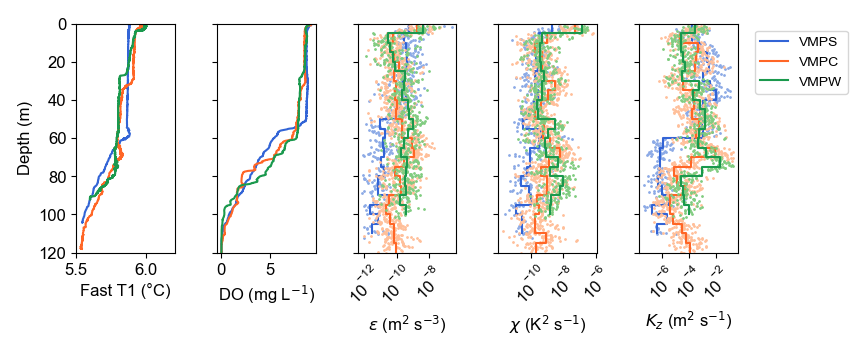

In [37]:
depthmax=120 # [m]

# Create a figure with specified size in centimeters
fig,ax = plt.subplots(1,5,figsize=(22 / 2.54, 9 / 2.54),sharey=True)  # Convert from cm to inches


# 1st plot: fast temperature
for kcat in range(len(categories)):
    ax[0].plot(dataprof[indcat[kcat][0]].FAST_fast_T1.data,dataprof[indcat[kcat][0]].FAST_depth,linewidth=1.5, color=colcat[kcat])
ax[0].set_xlabel('Fast T1 (°C)')

# 2nd subplot: DO
for kcat in range(len(categories)):
    ax[1].plot(dataprof_CTD["DO"][:,indcat_CTD[kcat][0]],dataprof_CTD["depth"],'-',linewidth=1.5, color=colcat[kcat])
ax[1].set_xlabel('DO (mg L$^{-1}$)')


# 2nd subplot: Eps-T1
for kcat in range(len(categories)):
    ax[2].plot(plot_data["eps_"]["values_all"][kcat], plot_data["eps_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
    ax[2].plot(10**plot_data["eps_"]["logmed"][kcat], plot_data["eps_"]["depth_cells"][kcat], '-', color=colcat[kcat],label=categories[kcat])
ax[2].set_xlabel(r'$\epsilon$ (m$^2$ s$^{-3}$)')
ax[2].set_xscale('log')
xlimval=ax[2].get_xlim()
ax[2].set_xticks(10.0**np.arange(-14, 1, 2))
ax[2].set_xlim(xlimval)
ax[2].tick_params(axis='x', labelrotation=45)
#ax[2].set_xlim([10**(-11), 10**(-4)])


# 2nd subplot: X-T1
for kcat in range(len(categories)):
    ax[3].plot(plot_data["Xi_"]["values_all"][kcat], plot_data["Xi_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
    ax[3].plot(10**plot_data["Xi_"]["logmed"][kcat], plot_data["Xi_"]["depth_cells"][kcat], '-', color=colcat[kcat],label=categories[kcat]) 
ax[3].set_xlabel(r'$\chi$ (K$^2$ s$^{-1}$)')
ax[3].set_xscale('log')
xlimval=ax[3].get_xlim()
ax[3].set_xticks(10.0**np.arange(-14, 1, 2))
ax[3].set_xlim(xlimval)
ax[3].tick_params(axis='x', labelrotation=45)
#ax[2].set_xlim([10**(-13), 10**(-6)])

# 3rd subplot: Kz-T1
for kcat in range(len(categories)):
    ax[4].plot(plot_data["KOsbornCox_"]["values_all"][kcat], plot_data["KOsbornCox_"]["depth_all"][kcat], 'o', markersize=1, markeredgecolor=colcat_light[kcat], markerfacecolor=colcat_light[kcat],rasterized=True)
    ax[4].plot(10**plot_data["KOsbornCox_"]["logmed"][kcat], plot_data["KOsbornCox_"]["depth_cells"][kcat], '-', color=colcat[kcat],label=categories[kcat])
ax[4].set_xlabel(r'$K_{z}$ (m$^2$ s$^{-1}$)')
ax[4].set_xscale('log')
xlimval=ax[4].get_xlim()
ax[4].set_xticks(10.0**np.arange(-14, 1, 2))
ax[4].set_xlim(xlimval)
ax[4].tick_params(axis='x', labelrotation=45)
ax[4].legend(loc='upper left',bbox_to_anchor=(1.1, 1), fontsize=10)
ax[0].set_ylabel('Depth (m)')

ax[0].set_ylim((0,depthmax))
ax[0].invert_yaxis()  # Reverse the y-axis 

fig.set_tight_layout(True)

# Save figure

if savefig:
    fig.savefig('comparison_turbulence_DO_'+campaign_name+'.png',dpi=400)
    #fig.savefig('comparison_turbulence_DO_'+campaign_name+'.svg',dpi=400)